# Phase 3: Tạo vòng 32 đội và mô phỏng knock-out

Notebook này tự nạp dữ liệu processed, tái tạo phần tối thiểu của engine vòng bảng từ notebook 02, rồi chuyển 32 đội đi tiếp vào bracket chính thức.

In [63]:
# MỤC TIÊU: nạp dữ liệu đã xử lý và các bảng quy định bracket.
# Notebook 03 không đọc dữ liệu Internet; nó dùng output của notebook 01.
from itertools import groupby
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Tách đường dẫn dữ liệu model và dữ liệu luật thi đấu để dễ bảo trì.
DATA_DIR = Path("data/processed")
REFERENCE_DIR = Path("data/reference")

# df_recent: các trận đã đá, dùng để fit model.
# upcoming_matches: các trận chưa đá, đã có Elo/form tại thời điểm dự báo.
df_recent = pd.read_csv(DATA_DIR / "matches_features.csv", parse_dates=["date"])
upcoming_matches = pd.read_csv(DATA_DIR / "upcoming_matches.csv", parse_dates=["date"])
group_letters = pd.read_csv(REFERENCE_DIR / "group_letters.csv")
r32_skeleton = pd.read_csv(REFERENCE_DIR / "r32_skeleton.csv", keep_default_na=False)
r32_combos = pd.read_csv(REFERENCE_DIR / "r32_combinations.csv")

# Fail fast: nếu assertion lỗi, hãy chạy lại notebook 01 trước.
assert df_recent["outcome"].notna().all()
assert upcoming_matches["outcome"].isna().all()
print("Đã đá:", df_recent.shape, "| Chưa đá:", upcoming_matches.shape)

Đã đá: (10784, 19) | Chưa đá: (32, 19)


## Model cần cho vòng bảng và knock-out

Logistic Regression cung cấp xác suất thắng/hòa/thua. Hai Poisson Regression tạo tỷ số để xếp hạng vòng bảng. Cả hai dùng Elo, sân trung lập, form 5 trận và trọng số ưu tiên dữ liệu gần hiện tại.

In [64]:
# Sáu feature form mô tả ba khía cạnh của mỗi đội trong 5 trận gần nhất:
# points_form = điểm/trận, gf_form = bàn thắng/trận, ga_form = bàn thua/trận.
FORM_FEATURES = [
    "home_points_form", "away_points_form",
    "home_gf_form", "away_gf_form",
    "home_ga_form", "away_ga_form",
]
# elo_diff đo chênh lệch sức mạnh dài hạn; form phản ánh trạng thái gần đây.
# neutral giúp model phân biệt sân trung lập với lợi thế sân nhà.
FINAL_FEATURES = ["elo_diff", "neutral"] + FORM_FEATURES
RECENCY_HALF_LIFE_YEARS = 4

def recency_weights(dates):
    """Trọng số giảm một nửa sau mỗi 4 năm; trận mới ảnh hưởng nhiều hơn trận cũ."""
    age_years = (dates.max() - dates).dt.days / 365.25
    return 0.5 ** (age_years / RECENCY_HALF_LIFE_YEARS)

full_weights = recency_weights(df_recent["date"])


def make_classifier():
    """Pipeline dự đoán home_win/draw/away_win."""
    # Imputer điền median cho đội chưa đủ lịch sử form.
    # Scaler đưa các feature về cùng thang đo trước Logistic Regression.
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=2000),
    )


def make_goal_model():
    """Pipeline Poisson dự đoán số bàn kỳ vọng (lambda)."""
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        PoissonRegressor(alpha=0.1, max_iter=2000),
    )


# Tạo ba model riêng: một model outcome và hai model số bàn.
final_model = make_classifier()
home_goal_model = make_goal_model()
away_goal_model = make_goal_model()
# Với Pipeline, sample_weight phải truyền tới step cuối bằng tên step__.
final_model.fit(
    df_recent[FINAL_FEATURES], df_recent["outcome"],
    logisticregression__sample_weight=full_weights,
)
home_goal_model.fit(
    df_recent[FINAL_FEATURES], df_recent["home_score"],
    poissonregressor__sample_weight=full_weights,
)
away_goal_model.fit(
    df_recent[FINAL_FEATURES], df_recent["away_score"],
    poissonregressor__sample_weight=full_weights,
)


def predict_outcome_probabilities(model, row, features=FINAL_FEATURES):
    """Đổi một dòng feature thành dict xác suất theo đúng tên class."""
    feature_row = pd.DataFrame([{feature: row[feature] for feature in features}])
    probabilities = model.predict_proba(feature_row)[0]
    classes = model.named_steps["logisticregression"].classes_
    return dict(zip(classes, probabilities))


def predict_goal_rates(row):
    """Trả về lambda bàn thắng của đội nhà và đội khách cho một trận."""
    # Clip tránh lambda bằng 0 hoặc quá cực đoan khi Poisson mô phỏng tỷ số.
    feature_row = pd.DataFrame([{feature: row[feature] for feature in FINAL_FEATURES}])
    home_rate = float(home_goal_model.predict(feature_row)[0])
    away_rate = float(away_goal_model.predict(feature_row)[0])
    return np.clip(home_rate, 0.05, 7.0), np.clip(away_rate, 0.05, 7.0)

In [65]:
# MỤC TIÊU: ghép phần vòng bảng đã đá với lịch chưa đá thành đúng 72 trận.
wc_played_all = df_recent[
    df_recent["tournament"].eq("FIFA World Cup")
    & df_recent["date"].ge("2026-01-01")
].copy()
wc_upcoming_all = upcoming_matches[
    upcoming_matches["tournament"].eq("FIFA World Cup")
].copy()

# World Cup 48 đội có 12 bảng × 6 trận/bảng = 72 trận vòng bảng.
# .head(72) ngăn các trận knock-out đã đá sau này lọt ngược vào vòng bảng.
wc_group_matches = (
    pd.concat([wc_played_all, wc_upcoming_all], ignore_index=True, sort=False)
    .sort_values(["date", "home_team", "away_team"])
    .head(72)
    .reset_index(drop=True)
)
wc2026_played = wc_group_matches.dropna(subset=["home_score", "away_score"]).copy()
wc2026_upcoming = wc_group_matches[
    wc_group_matches[["home_score", "away_score"]].isna().any(axis=1)
].copy()

# Hai assertion xác nhận đủ lịch và đúng 48 đội trong file group_letters.
assert len(wc_group_matches) == 72
assert set(wc_group_matches["home_team"]) | set(wc_group_matches["away_team"]) == set(group_letters["team"])
print("Vòng bảng đã đá:", len(wc2026_played), "| Còn lại:", len(wc2026_upcoming))

Vòng bảng đã đá: 40 | Còn lại: 32


In [66]:
# Mỗi trận chưa đá nhận hai lambda Poisson: bàn kỳ vọng home và away.
goal_rates = wc2026_upcoming.apply(predict_goal_rates, axis=1, result_type="expand")
goal_rates.columns = ["home_goal_rate", "away_goal_rate"]
wc2026_upcoming = pd.concat(
    [wc2026_upcoming.reset_index(drop=True), goal_rates.reset_index(drop=True)],
    axis=1,
)
assert wc2026_upcoming[["home_goal_rate", "away_goal_rate"]].notna().all().all()

## Engine xếp hạng lấy từ notebook 02

`calculate_table()` tạo thống kê; `rank_group()` trả về danh sách đã xếp hạng từ nhất đến tư. Nếu mọi tie-break có dữ liệu đều bằng nhau, seed của `rng` quyết định bốc thăm.

In [67]:
def calculate_table(teams, results):
    """Tính points, goals for/against và goal difference; chưa xếp hạng."""
    table = {team: {"team": team, "points": 0, "gf": 0, "ga": 0} for team in teams}
    # Mỗi result có dạng: (home_team, away_team, home_goals, away_goals).
    for home, away, home_goals, away_goals in results:
        if home not in table or away not in table:
            continue
        table[home]["gf"] += home_goals
        table[home]["ga"] += away_goals
        table[away]["gf"] += away_goals
        table[away]["ga"] += home_goals
        if home_goals > away_goals:
            table[home]["points"] += 3
        elif home_goals < away_goals:
            table[away]["points"] += 3
        else:
            table[home]["points"] += 1
            table[away]["points"] += 1

    for row in table.values():
        row["gd"] = row["gf"] - row["ga"]
    return table


def rank_group(teams, results, rng):
    """Trả về list 4 đội đã xếp từ hạng nhất đến hạng tư."""
    overall = calculate_table(teams, results)
    rows = sorted(
        overall.values(),
        key=lambda row: (row["points"], row["gd"], row["gf"]),
        reverse=True,
    )

    # Chỉ những đội bằng cả points/gd/gf mới cần xét đối đầu.
    ranked = []
    ranking_key = lambda row: (row["points"], row["gd"], row["gf"])
    for _, tied_rows in groupby(rows, key=ranking_key):
        tied_rows = list(tied_rows)
        if len(tied_rows) == 1:
            ranked.extend(tied_rows)
            continue

        # Tạo mini-table chỉ gồm các đội đang bằng nhau để xét head-to-head.
        tied_teams = {row["team"] for row in tied_rows}
        head_to_head = calculate_table(tied_teams, results)
        # Không có dữ liệu fair-play, nên bốc thăm có seed là tie-break cuối.
        lottery = {team: rng.random() for team in tied_teams}
        tied_rows.sort(
            key=lambda row: (
                head_to_head[row["team"]]["points"],
                head_to_head[row["team"]]["gd"],
                head_to_head[row["team"]]["gf"],
                lottery[row["team"]],
            ),
            reverse=True,
        )
        ranked.extend(tied_rows)
    return ranked

In [68]:
# MỤC TIÊU: đóng gói mỗi bảng thành một object độc lập để mô phỏng nhanh.
group_data = []
for letter, mapping in group_letters.groupby("group_letter", sort=True):
    teams = tuple(mapping["team"])
    played = wc2026_played[
        wc2026_played["home_team"].isin(teams)
        & wc2026_played["away_team"].isin(teams)
    ]
    future = wc2026_upcoming[
        wc2026_upcoming["home_team"].isin(teams)
        & wc2026_upcoming["away_team"].isin(teams)
    ]
    # Trận đã đá giữ nguyên tỷ số thật; trận tương lai giữ lambda để random sau.
    played_results = [
        (row.home_team, row.away_team, int(row.home_score), int(row.away_score))
        for row in played.itertuples(index=False)
    ]
    future_matches = [
        (row.home_team, row.away_team, row.home_goal_rate, row.away_goal_rate)
        for row in future.itertuples(index=False)
    ]
    # Mỗi bảng 4 đội phải có đúng C(4,2)=6 trận.
    assert len(played_results) + len(future_matches) == 6
    group_data.append({
        "letter": letter,
        "teams": teams,
        "played": played_results,
        "future": future_matches,
    })

print("Số bảng:", len(group_data))

Số bảng: 12


In [69]:
def simulate_group(group_info, rng):
    """Mô phỏng trận còn lại và trả về bảng xếp hạng hoàn chỉnh."""
    results = list(group_info["played"])
    for home, away, home_rate, away_rate in group_info["future"]:
        # Poisson biến số bàn kỳ vọng thành tỷ số nguyên cho một kịch bản.
        home_goals = int(rng.poisson(home_rate))
        away_goals = int(rng.poisson(away_rate))
        results.append((home, away, home_goals, away_goals))
    return rank_group(group_info["teams"], results, rng)

## Chuyển kết quả vòng bảng sang vòng 32 đội

In [70]:
def best_eight_third_place(third_place_by_group, rng):
    """So sánh 12 đội hạng ba và trả về 8 chữ cái bảng được đi tiếp."""
    rows = [{"group": letter, **stats} for letter, stats in third_place_by_group.items()]
    ranking = pd.DataFrame(rows)
    ranking["lottery"] = rng.random(len(ranking))
    ranking = ranking.sort_values(
        ["points", "gd", "gf", "lottery"],
        ascending=False,
    )
    return set(ranking["group"].iloc[:8])


def resolve_round_of_32(winner_by_group, runnerup_by_group, third_by_group, advancing_third_letters):
    """Điền tên đội vào 16 slot R32 theo bảng tổ hợp chính thức."""
    # Ví dụ key 'A,C,D,F,G,H,I,L' chọn đúng cách phân đội hạng ba cho các bảng.
    advancing_key = ",".join(sorted(advancing_third_letters))
    matching_combo = r32_combos[r32_combos["advancing_groups"].eq(advancing_key)]
    if matching_combo.empty:
        raise ValueError(f"Không tìm thấy tổ hợp đội hạng ba: {advancing_key}")
    combo = matching_combo.iloc[0]

    matches = []
    for _, slot in r32_skeleton.iterrows():
        home_source = runnerup_by_group if slot["home_type"] == "RU" else winner_by_group
        home = home_source[slot["home_group"]]
        if slot["away_type"] == "3rd":
            third_letter = combo[f"vs_1{slot['home_group']}"]
            away = third_by_group[third_letter]
        else:
            away_source = runnerup_by_group if slot["away_type"] == "RU" else winner_by_group
            away = away_source[slot["away_group"]]
        matches.append({
            "match_no": int(slot["match_no"]),
            "home_team": home,
            "away_team": away,
        })
    return pd.DataFrame(matches)

In [71]:
def run_group_stage_full(group_data, rng):
    """Chạy toàn bộ vòng bảng và trả về 32 đội cùng 16 cặp R32."""
    standings_by_group = {
        group_info["letter"]: simulate_group(group_info, rng)
        for group_info in group_data
    }

    # rank_group đã sắp thứ tự, nên index 0/1/2 tương ứng nhất/nhì/ba.
    winner_by_group = {letter: table[0]["team"] for letter, table in standings_by_group.items()}
    runnerup_by_group = {letter: table[1]["team"] for letter, table in standings_by_group.items()}
    third_by_group = {letter: table[2]["team"] for letter, table in standings_by_group.items()}
    third_stats = {
        letter: {"points": table[2]["points"], "gd": table[2]["gd"], "gf": table[2]["gf"]}
        for letter, table in standings_by_group.items()
    }

    advancing_third_letters = best_eight_third_place(third_stats, rng)
    # 12 nhất + 12 nhì + 8 hạng ba = 32 đội.
    qualified = set(winner_by_group.values()) | set(runnerup_by_group.values()) | {
        third_by_group[letter] for letter in advancing_third_letters
    }
    assert len(qualified) == 32

    r32_matches = resolve_round_of_32(
        winner_by_group,
        runnerup_by_group,
        third_by_group,
        advancing_third_letters,
    )
    assert len(r32_matches) == 16
    return qualified, r32_matches

In [72]:
rng_test = np.random.default_rng(1)
qualified, r32_matches = run_group_stage_full(group_data, rng_test)

print("Số đội đi tiếp:", len(qualified))
r32_matches

Số đội đi tiếp: 32


,match_no,home_team,away_team
0,73,South Korea,Switzerland
1,74,Germany,Paraguay
2,75,Japan,Morocco
3,76,Scotland,Netherlands
4,77,France,Sweden
5,78,Ivory Coast,Norway
6,79,Mexico,Brazil
7,80,England,Uzbekistan
8,81,United States,Senegal
9,82,Egypt,Uruguay


## Helper chọn đội thắng trận knock-out

Nếu hòa sau thời gian thi đấu, phiên bản đơn giản dưới đây chia cơ hội đi tiếp 50–50. Có thể thay `penalty_home_probability` khi có model hiệp phụ/luân lưu riêng.

In [73]:
def knockout_result(model, row, rng, penalty_home_probability=0.5):
    """Chọn đội đi tiếp; phần xác suất hòa được chuyển sang hiệp phụ/luân lưu."""
    probabilities = predict_outcome_probabilities(model, row)
    # Bản đơn giản giả định hai đội có cơ hội 50-50 nếu hòa sau 90 phút.
    p_home_advance = (
        probabilities["home_win"]
        + probabilities["draw"] * penalty_home_probability
    )
    return rng.choice(
        ["home_win", "away_win"],
        p=[p_home_advance, 1 - p_home_advance],
    )

# 1. Tạo Elo hiện tại cho 48 đội

In [74]:
# MỤC TIÊU: tạo snapshot sức mạnh hiện tại theo tên đội để dùng cho cặp đấu mới.
home_elo = upcoming_matches[
    ["home_team", "home_elo_now"]
].rename(columns={
    "home_team": "team",
    "home_elo_now": "elo",
})

away_elo = upcoming_matches[
    ["away_team", "away_elo_now"]
].rename(columns={
    "away_team": "team",
    "away_elo_now": "elo",
})

elo_now = (
    pd.concat([home_elo, away_elo])
    .drop_duplicates("team")
    .set_index("team")["elo"]
    .to_dict()
)

# Gộp form home/away về một cấu trúc chung: team -> form hiện tại.
team_form_now = {}
for row in upcoming_matches.itertuples(index=False):
    for side in ["home", "away"]:
        team = getattr(row, f"{side}_team")
        team_form_now[team] = {
            "points_form": getattr(row, f"{side}_points_form"),
            "gf_form": getattr(row, f"{side}_gf_form"),
            "ga_form": getattr(row, f"{side}_ga_form"),
        }

missing_elo = qualified - set(elo_now)
missing_form = qualified - set(team_form_now)
assert not missing_elo, f"Thiếu Elo: {missing_elo}"
assert not missing_form, f"Thiếu form: {missing_form}"

# 2. Viết hàm mô phỏng một trận knock-out

In [75]:
def simulate_knockout_game(home_team, away_team, rng):
    """Tạo feature cho cặp đấu bất kỳ và trả về (winner, loser)."""
    home_form = team_form_now[home_team]
    away_form = team_form_now[away_team]
    # Knock-out chưa có dòng trong upcoming_matches, nên feature phải dựng thủ công.
    match_features = pd.Series({
        "elo_diff": elo_now[home_team] - elo_now[away_team],
        "neutral": True,
        "home_points_form": home_form["points_form"],
        "away_points_form": away_form["points_form"],
        "home_gf_form": home_form["gf_form"],
        "away_gf_form": away_form["gf_form"],
        "home_ga_form": home_form["ga_form"],
        "away_ga_form": away_form["ga_form"],
    })

    result = knockout_result(
        final_model,
        match_features,
        rng,
        penalty_home_probability=0.5,
    )

    if result == "home_win":
        return home_team, away_team

    return away_team, home_team

# 3. Mô phỏng vòng 32 đội

In [76]:
# Seed cố định giúp ví dụ một lần chạy có thể tái lập khi học/debug.
rng_knockout = np.random.default_rng(1)

r32_results = []

# Đi qua 16 cặp R32 và lưu cả winner lẫn loser cho bracket sau.
for row in r32_matches.itertuples(index=False):
    winner, loser = simulate_knockout_game(
        row.home_team,
        row.away_team,
        rng_knockout,
    )

    r32_results.append({
        "match_no": row.match_no,
        "home_team": row.home_team,
        "away_team": row.away_team,
        "winner": winner,
        "loser": loser,
    })

r32_results = pd.DataFrame(r32_results)
r32_results

,match_no,home_team,away_team,winner,loser
0,73,South Korea,Switzerland,South Korea,Switzerland
1,74,Germany,Paraguay,Paraguay,Germany
2,75,Japan,Morocco,Japan,Morocco
3,76,Scotland,Netherlands,Netherlands,Scotland
4,77,France,Sweden,France,Sweden
5,78,Ivory Coast,Norway,Ivory Coast,Norway
6,79,Mexico,Brazil,Brazil,Mexico
7,80,England,Uzbekistan,England,Uzbekistan
8,81,United States,Senegal,United States,Senegal
9,82,Egypt,Uruguay,Egypt,Uruguay


# 4. Nối các vòng còn lại

In [77]:
# Skeleton mô tả trận sau lấy winner/loser từ match_no nào trước đó.
later_rounds = pd.read_csv(
    "data/reference/later_rounds_skeleton.csv",
    dtype=str,
)

match_results = {
    int(row.match_no): {
        "winner": row.winner,
        "loser": row.loser,
    }
    for row in r32_results.itertuples(index=False)
}


def resolve_source(source):
    """Đổi source '89' hoặc 'loser_101' thành tên đội cụ thể."""
    source = str(source)

    if source.startswith("loser_"):
        match_no = int(source.removeprefix("loser_"))
        return match_results[match_no]["loser"]

    return match_results[int(source)]["winner"]


later_results = []

# File đã được sắp theo R16 -> QF -> SF -> hạng ba -> chung kết.
for _, slot in later_rounds.iterrows():
    home_team = resolve_source(slot["home_source_match"])
    away_team = resolve_source(slot["away_source_match"])

    winner, loser = simulate_knockout_game(
        home_team,
        away_team,
        rng_knockout,
    )

    match_no = int(slot["match_no"])

    match_results[match_no] = {
        "winner": winner,
        "loser": loser,
    }

    later_results.append({
        "round": slot["round"],
        "match_no": match_no,
        "home_team": home_team,
        "away_team": away_team,
        "winner": winner,
    })

later_results = pd.DataFrame(later_results)
later_results

,round,match_no,home_team,away_team,winner
0,R16,89,Paraguay,France,Paraguay
1,R16,90,South Korea,Japan,South Korea
2,R16,91,Netherlands,Ivory Coast,Netherlands
3,R16,92,Brazil,England,Brazil
4,R16,93,Panama,Spain,Spain
5,R16,94,United States,Egypt,United States
6,R16,95,Saudi Arabia,Australia,Australia
7,R16,96,Canada,Portugal,Portugal
8,QF,97,Paraguay,South Korea,South Korea
9,QF,98,Spain,United States,Spain


In [82]:
print("KỊCH BẢN MINH HỌA — không phải dự báo cuối:")
print("Vô địch:", match_results[104]["winner"])
print("Á quân:", match_results[104]["loser"])
print("Hạng ba:", match_results[103]["winner"])

KỊCH BẢN MINH HỌA — không phải dự báo cuối:
Vô địch: South Korea
Á quân: Australia
Hạng ba: Spain


# 5. Monte Carlo toàn giải

Một lần mô phỏng chỉ là một kịch bản. Phần này cache xác suất từng cặp knock-out và chạy toàn bộ giải 10.000 lần bằng một RNG xuyên suốt.

In [79]:
def knockout_feature_row(home_team, away_team):
    """Dựng đủ 8 feature cho một cặp knock-out chưa tồn tại trong dữ liệu."""
    home_form = team_form_now[home_team]
    away_form = team_form_now[away_team]
    return pd.Series({
        "elo_diff": elo_now[home_team] - elo_now[away_team],
        "neutral": True,
        "home_points_form": home_form["points_form"],
        "away_points_form": away_form["points_form"],
        "home_gf_form": home_form["gf_form"],
        "away_gf_form": away_form["gf_form"],
        "home_ga_form": home_form["ga_form"],
        "away_ga_form": away_form["ga_form"],
    })


# Có 48×47=2256 cặp có thứ tự. Cache một lần để 10.000 mô phỏng chạy nhanh.
all_world_cup_teams = sorted(set(group_letters["team"]))
knockout_home_probability = {}
for home_team in all_world_cup_teams:
    for away_team in all_world_cup_teams:
        if home_team == away_team:
            continue
        probabilities = predict_outcome_probabilities(
            final_model, knockout_feature_row(home_team, away_team)
        )
        # Nếu hòa sau 90 phút, chia xác suất đi tiếp 50-50.
        knockout_home_probability[(home_team, away_team)] = (
            probabilities["home_win"] + 0.5 * probabilities["draw"]
        )

print("Số cặp knock-out đã cache:", len(knockout_home_probability))

Số cặp knock-out đã cache: 2256


In [80]:
def simulate_cached_knockout(home_team, away_team, rng):
    """Rút một kết quả Bernoulli từ xác suất đã cache."""
    home_wins = rng.random() < knockout_home_probability[(home_team, away_team)]
    return (home_team, away_team) if home_wins else (away_team, home_team)


def simulate_full_tournament(rng):
    """Mô phỏng từ các trận vòng bảng còn lại đến trận chung kết."""
    _, simulated_r32 = run_group_stage_full(group_data, rng)
    results = {}

    # Bước 1: mô phỏng 16 trận vòng 32 và lưu kết quả theo match_no.
    for row in simulated_r32.itertuples(index=False):
        winner, loser = simulate_cached_knockout(row.home_team, row.away_team, rng)
        results[int(row.match_no)] = {"winner": winner, "loser": loser}

    semifinalists = set()
    finalists = set()
    # Bước 2: lần lượt giải các source match để chạy R16 -> Final.
    for _, slot in later_rounds.iterrows():
        def source_team(source):
            source = str(source)
            if source.startswith("loser_"):
                return results[int(source.removeprefix("loser_"))]["loser"]
            return results[int(source)]["winner"]

        home_team = source_team(slot["home_source_match"])
        away_team = source_team(slot["away_source_match"])
        if slot["round"] == "SF":
            semifinalists.update([home_team, away_team])
        elif slot["round"] == "Final":
            finalists.update([home_team, away_team])

        winner, loser = simulate_cached_knockout(home_team, away_team, rng)
        results[int(slot["match_no"])] = {"winner": winner, "loser": loser}

    return {
        "champion": results[104]["winner"],
        "runner_up": results[104]["loser"],
        "third_place": results[103]["winner"],
        "semifinalists": semifinalists,
        "finalists": finalists,
    }

In [81]:
# 10.000 lần cho sai số Monte Carlo khoảng dưới 0,5 điểm % ở xác suất lớn.
N_TOURNAMENT_SIMULATIONS = 10_000
rng_monte_carlo = np.random.default_rng(2026)
champion_count = {team: 0 for team in all_world_cup_teams}
final_count = {team: 0 for team in all_world_cup_teams}
semifinal_count = {team: 0 for team in all_world_cup_teams}

# Mỗi lần dùng tiếp cùng RNG; không reset seed bên trong vòng lặp.
for _ in range(N_TOURNAMENT_SIMULATIONS):
    simulation = simulate_full_tournament(rng_monte_carlo)
    champion_count[simulation["champion"]] += 1
    for team in simulation["finalists"]:
        final_count[team] += 1
    for team in simulation["semifinalists"]:
        semifinal_count[team] += 1

# Chuyển số lần xuất hiện thành xác suất và sắp theo khả năng vô địch.
tournament_probabilities = (
    pd.DataFrame({
        "team": all_world_cup_teams,
        "semifinal_probability": [semifinal_count[team] / N_TOURNAMENT_SIMULATIONS for team in all_world_cup_teams],
        "final_probability": [final_count[team] / N_TOURNAMENT_SIMULATIONS for team in all_world_cup_teams],
        "champion_probability": [champion_count[team] / N_TOURNAMENT_SIMULATIONS for team in all_world_cup_teams],
    })
    .sort_values("champion_probability", ascending=False)
    .reset_index(drop=True)
)
tournament_probabilities.head(20)

,team,semifinal_probability,final_probability,champion_probability
0,Spain,0.4426,0.2781,0.1918
1,France,0.2823,0.1682,0.0999
2,Germany,0.2787,0.1481,0.0844
3,Argentina,0.2802,0.1395,0.0631
4,England,0.2072,0.1260,0.0618
5,Japan,0.2035,0.1174,0.0612
6,Mexico,0.2144,0.1280,0.0549
7,Morocco,0.1710,0.1008,0.0494
8,United States,0.1905,0.0793,0.0419
9,Iran,0.1530,0.0760,0.0381


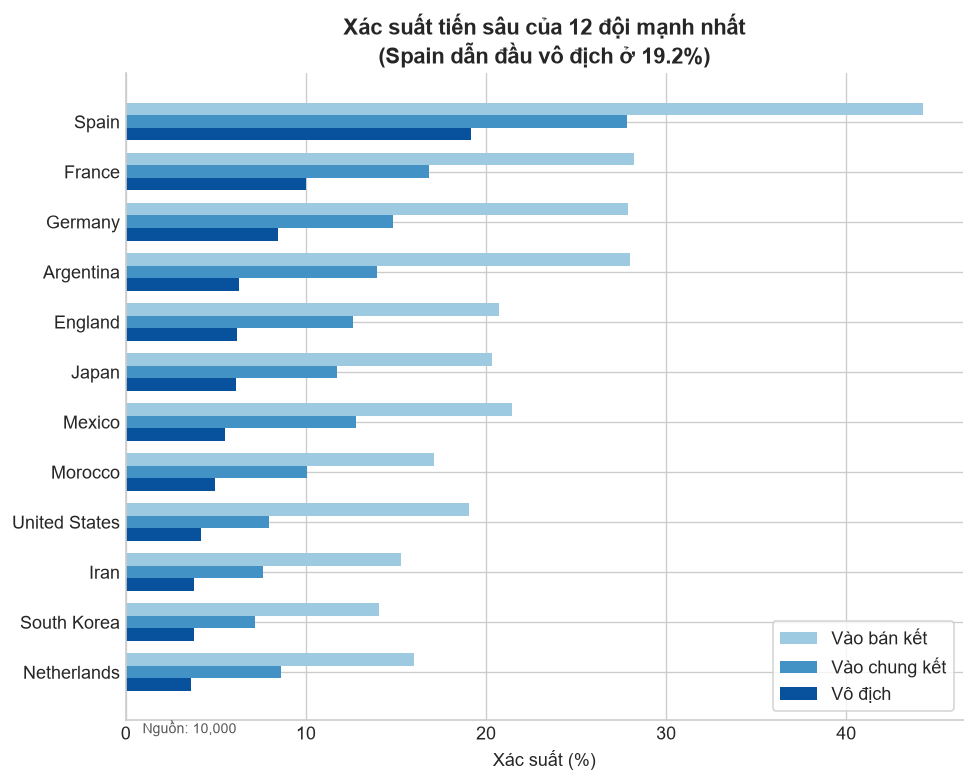

In [86]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

TOP_N = 12
top_teams = tournament_probabilities.head(TOP_N).iloc[::-1]  # đảo để vô địch nằm trên cùng khi vẽ ngang

fig, ax = plt.subplots(figsize=(9, 7))

bar_height = 0.25
y = range(len(top_teams))

ax.barh([i + bar_height for i in y], top_teams["semifinal_probability"] * 100,
        height=bar_height, label="Vào bán kết", color="#9ecae1")
ax.barh([i for i in y], top_teams["final_probability"] * 100,
        height=bar_height, label="Vào chung kết", color="#4292c6")
ax.barh([i - bar_height for i in y], top_teams["champion_probability"] * 100,
        height=bar_height, label="Vô địch", color="#08519c")

ax.set_yticks(list(y))
ax.set_yticklabels(top_teams["team"])
ax.set_xlabel("Xác suất (%)")
ax.set_title(
    f"Xác suất tiến sâu của {TOP_N} đội mạnh nhất\n"
    f"({tournament_probabilities.iloc[0]['team']} dẫn đầu vô địch ở "
    f"{tournament_probabilities.iloc[0]['champion_probability']*100:.1f}%)",
    fontweight="bold",
)
ax.legend(loc="lower right", frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.02, -0.02,
         f"Nguồn: {N_TOURNAMENT_SIMULATIONS:,}",
         fontsize=8.5, color="#555555", transform=ax.transAxes)

import os
SAVE_FIGURES = os.getenv("WC2026_SAVE_FIGURES", "1") != "0"
if SAVE_FIGURES:
    os.makedirs("docs", exist_ok=True)
    plt.savefig("docs/top_contenders.png", dpi=150, bbox_inches="tight")
plt.show()

So sánh với Opta (do Codex review): 
Đánh giá công bằng
Model của bạn đang ở mức tốt cho một dự án data science:
Có temporal validation.
Không rò rỉ dữ liệu form.
Log loss World Cup khoảng 0,977.
Có Poisson, tie-break và Monte Carlo toàn giải.
Nhưng Opta vẫn có lợi thế lớn về dữ liệu, market odds, calibration và độ sâu lịch sử. Bài Opta không công bố log loss/Brier score trên cùng tập test, nên không thể chứng minh bằng số rằng Opta chính xác hơn; tuy nhiên xét về thiết kế và nguồn dữ liệu, Opta gần như chắc chắn mạnh hơn.
Muốn so sánh thực sự, cần tạo một phiên bản model của bạn tại đúng thời điểm pre-draw, sau đó backtest cả hai bằng log loss hoặc Brier score trên cùng các trận.

In [87]:
elo_now["Brazil"], team_form_now["Brazil"]

(1752.956485317404, {'points_form': 1.4, 'gf_form': 1.8, 'ga_form': 1.0})

In [88]:
tournament_probabilities[["semifinal_probability", "final_probability", "champion_probability"]].sum()

semifinal_probability    4.0
final_probability        2.0
champion_probability     1.0
dtype: float64

In [89]:
for team in ["Brazil", "Japan", "Spain"]:
    print(team, "-> elo:", round(elo_now[team], 1), "| form:", team_form_now[team])

Brazil -> elo: 1753.0 | form: {'points_form': 1.4, 'gf_form': 1.8, 'ga_form': 1.0}
Japan -> elo: 1827.6 | form: {'points_form': 2.6, 'gf_form': 2.8, 'ga_form': 0.8}
Spain -> elo: 1891.0 | form: {'points_form': 2.2, 'gf_form': 2.8, 'ga_form': 0.4}
